### Exercises

### 1

In [2]:
import torch
from collections import Counter

In [15]:
class Vocab:
  def __init__(self, tokens, reserved_words=[], min_freq=0):
    hist = Counter(tokens)
    self.token_freq = sorted(hist.items(), key=lambda x: x[1], reverse=True)
    self.tokens = list(set(reserved_words + ['<unk>'] + [token for token, freq in self.token_freq if freq >= min_freq]))
    self.reverse_map = {token: idx for idx, token in enumerate(self.tokens)}
  def __len__(self):
    return len(self.tokens)
  def __getitem__(self, token):
    if(isinstance(token, (list, tuple))):
      return [self.__getitem__(i) for i in token]
    else:
      return self.reverse_map.get(token, self.unk)
  def get_tokens(self, idxs):
    if(isinstance(idxs, (list, tuple))):
      return [self.tokens[i] for i in idxs]
    else:
      return self.tokens[idxs]
  @property
  def unk(self):
    return self.reverse_map['<unk>']

In [16]:
time_machine_url = 'https://www.gutenberg.org/cache/epub/35/pg35.txt'
import requests

In [17]:
corpus = requests.get(time_machine_url).text

In [18]:
words =  corpus.lower().split()

In [22]:
min_freq_pl, len_pl = [], []
for min_freq in range(5, 500, 10):
  vocab = Vocab(words, min_freq=min_freq)
  min_freq_pl.append(min_freq)
  len_pl.append(len(vocab))

In [23]:
from matplotlib import pyplot as plt

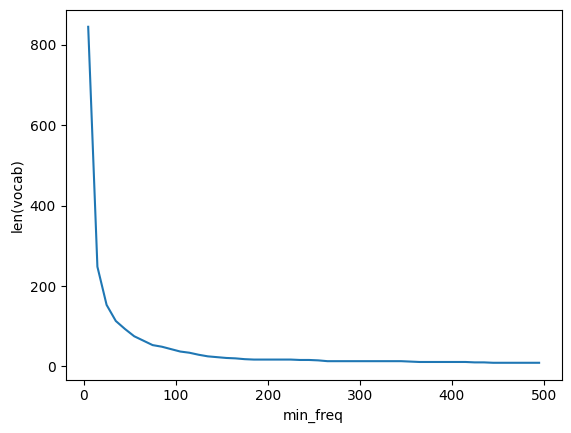

In [24]:
plt.plot(min_freq_pl, len_pl)
plt.xlabel('min_freq')
plt.ylabel('len(vocab)')
plt.show()

### 2

In [44]:
def Zipfian(wordx):
  unigram_vocab = Vocab(wordx)
  input_idx = list(range(1, len(unigram_vocab.token_freq) + 1))
  ouput_freq = list(map(lambda x: x[1], unigram_vocab.token_freq))
  input_tensor = torch.log(torch.tensor(input_idx))
  output_tensor = torch.log(torch.tensor(ouput_freq))
  linear_model = torch.nn.Linear(1, 1)
  optimizer = torch.optim.SGD(linear_model.parameters(), lr=0.01)
  loss = torch.nn.MSELoss()
  dataset = torch.utils.data.TensorDataset(input_tensor, output_tensor)
  dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)
  for X, y in dataloader:
    optimizer.zero_grad()
    y_pred = linear_model(X)
    l = loss(y_pred, y)
    l.backward()
    optimizer.step()
  print(f'epoch: {epoch}, loss: {l.item()}')
  weights = linear_model.weight.item()
  bias = linear_model.bias.item()
  return weights, bias

In [45]:
# Get the learned coefficients (weights and bias)
weights, bias = Zipfian(words)

print(f'Learned weights: {weights}')
print(f'Learned bias: {bias}')

epoch: 0, loss: 0.2958923280239105
Learned weights: -0.7214798927307129
Learned bias: 6.574909210205078


In [47]:
bigrams = ['--'.join([words[i], words[i + 1]]) for i in range(len(words) - 1)]
print(len(bigrams))

35482


In [48]:
weights, bias = Zipfian(bigrams)

print(f'Learned weights: {weights}')
print(f'Learned bias: {bias}')

epoch: 0, loss: 0.1870969831943512
Learned weights: -0.42360979318618774
Learned bias: 3.85848069190979


In [50]:
trigrams = ['--'.join([words[i], words[i + 1], words[i + 2]]) for i in range(len(words) - 2)]

In [51]:
weights, bias = Zipfian(trigrams)

print(f'Learned weights: {weights}')
print(f'Learned bias: {bias}')

epoch: 0, loss: 0.38238874077796936
Learned weights: -0.20390331745147705
Learned bias: 1.4139899015426636


### 3

**Macbeth**

In [52]:
words = requests.get('https://www.gutenberg.org/files/1533/1533-0.txt').text.lower().split()

In [53]:
min_freq_pl, len_pl = [], []
for min_freq in range(5, 500, 10):
  vocab = Vocab(words, min_freq=min_freq)
  min_freq_pl.append(min_freq)
  len_pl.append(len(vocab))

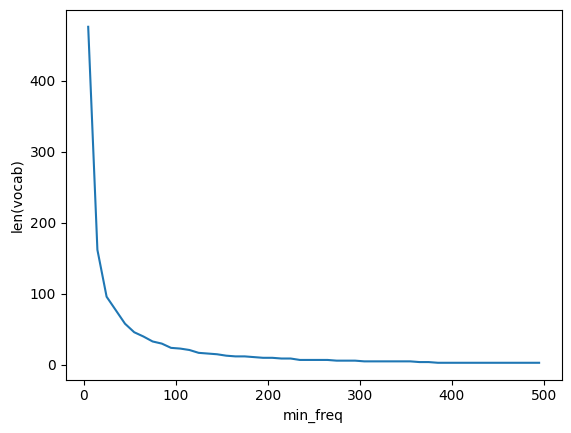

In [54]:
plt.plot(min_freq_pl, len_pl)
plt.xlabel('min_freq')
plt.ylabel('len(vocab)')
plt.show()

In [55]:
weights, bias = Zipfian(words)

print(f'Learned weights: {weights}')
print(f'Learned bias: {bias}')

epoch: 0, loss: 0.027892284095287323
Learned weights: -0.6666231155395508
Learned bias: 5.309702396392822


Conclusion: Same same